In [2]:
import pandas as pd
import contractions
import unicodedata
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

In [3]:
df = pd.read_csv("hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip")

/Users/ryn/Documents/ML_TextSetiments/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
from textCleaning import clean_text

In [6]:
df["review"] = df["review"].apply(clean_text)

In [8]:
df["review"].head()

0    one of the other reviewer ha mentioned that af...
1    a wonderful little production br br the filmin...
2    i thought this wa a wonderful way to spend tim...
3    basically there is a family where a little boy...
4    petter mattei 's `` love in the time of money ...
Name: review, dtype: object

In [7]:
import matplotlib.pyplot as plt

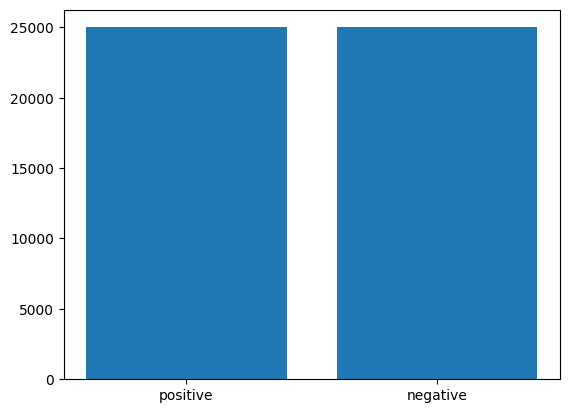

In [9]:
y = df["sentiment"].value_counts()
x = y.index
plt.bar(x,y)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(df["review"],df["sentiment"],test_size=0.2,random_state=42)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
tfid = TfidfVectorizer()
X_train_tfid = tfid.fit_transform(X_train)
X_test_tfid = tfid.transform(X_test)

In [14]:
from sklearn import svm

In [ ]:
tfid_svm = svm.SVC(kernel='linear')
tfid_svm.fit(X_train_tfid,y_train)
prediction = tfid_svm.predict(X_test_tfid[0])
print(prediction)

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
tfid_nb = GaussianNB(),
tfid_nb.fit(X_train_tfid.toarray(),y_train)
tfid_nb.predict(X_test_tfid.toarray()[0].reshape(1,-1))

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
tfid_lr = LogisticRegression()
tfid_lr.fit(X_train_tfid,y_train)
tfid_lr.predict(X_test_tfid[0])

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tfid_dt = DecisionTreeClassifier()
tfid_dt.fit(X_train_tfid,y_train),
prediction = tfid_dt.predict(X_test_tfid[0].reshape(1, -1))
print(prediction)

In [ ]:
from sklearn.metrics import score

In [ ]:
svm_score = tfid_svm.score(X_test_tfid,y_test)
nb_score = tfid_nb.score(X_test_tfid.toarray(),y_test)
lr_score = tfid_lr.score(X_test_tfid,y_test)
dt_score = tfid_dt.score(X_test_tfid,y_test)
x = ["SVM","Naive Bayes","Logistic Regression","Decision Tree"]
y = [svm_score,nb_score,lr_score,dt_score]
plt.bar(x,y)
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score

In [ ]:
labels_data = ["positive", "negative"]
f1_score_svm = f1_score(y_test, tfid_svm.predict(X_test_tfid), average=None, labels=labels_data)
f1_score_nb = f1_score(y_test, tfid_nb.predict(X_test_tfid.toarray()), average=None, labels=labels_data)
f1_score_l2 = f1_score(y_test, tfid_lr.predict(X_test_tfid), average=None, labels=labels_data)
f1_score_dt = f1_score(y_test, tfid_dt.predict(X_test_tfid), average=None, labels=labels_data)

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].bar(labels_data, f1_score_svm)
ax[0, 0].set_title("SVM F1 Score")
ax[0, 1].bar(labels_data, f1_score_nb)
ax[0, 1].set_title("Naive Bayes F1 Score")
ax[1, 0].bar(labels_data, f1_score_l2)
ax[1, 0].set_title("Logistic Regression F1 Score")
ax[1, 1].bar(labels_data, f1_score_dt)
ax[1, 1].set_title("Decision Tree F1 Score")

In [ ]:
labels_data = ["positive","negative"]
precision_score_svm = precision_score(y_test, tfid_svm.predict(X_test_tfid), average=None, labels=labels_data)
precision_score_nb = precision_score(y_test, tfid_nb.predict(X_test_tfid.toarray()), average=None, labels=labels_data)
precision_score_l2 = precision_score(y_test, tfid_lr.predict(X_test_tfid), average=None, labels=labels_data)
precision_score_dt = precision_score(y_test, tfid_dt.predict(X_test_tfid), average=None, labels=labels_data)

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].bar(labels_data, precision_score_svm)
ax[0, 0].set_title("SVM Precision Score")
ax[0, 1].bar(labels_data, precision_score_nb)
ax[0, 1].set_title("Naive Bayes Precision Score")
ax[1, 0].bar(labels_data, precision_score_l2)
ax[1, 0].set_title("Logistic Regression Precision Score")
ax[1, 1].bar(labels_data, precision_score_dt)
ax[1, 1].set_title("Decision Tree Precision Score")

In [ ]:
import pickle

In [ ]:
pickle.dump(tfid_svm, open("svm.pkl", "wb"))
pickle.dump(tfid, open("triVec.pkl", "wb"))